# Lab One: Simulating ODEs and SDEs

In [1]:
from abc import ABC, abstractmethod

import torch
from tqdm import tqdm
from typing import Optional
from matplotlib import pyplot as plt
from matplotlib.axes._axes import Axes

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 0: Introduction

First, let us make precise the central objects of study: *ordinary differential equations* (ODEs) and *stochastic differential equations* (SDEs). The basis of both ODEs and SDEs are time-dependent *vector fields*, which we recall from lecture as being functions $u$ defined by $$u:\mathbb{R}^d\times [0,1]\to \mathbb{R}^d,\quad (x,t)\mapsto u_t(x)$$
That is, $u_t(x)$ takes in *where in space we are* ($x$) and *where in time we are* ($t$), and spits out the *direction we should be going in* $u_t(x)$. An ODE is then given by $$d X_t = u_t(X_t)dt, \quad \quad X_0 = x_0.$$
Similarly, an SDE is of the form $$d X_t = u_t(X_t)dt + \sigma_t d W_t, \quad \quad X_0 = x_0,$$
which can be thought of as starting with an ODE given by $u_t$, and adding noise via the *Brownian motion* $(W_t)_{0 \le t \le 1}$. The amount of noise that we add is given by the *diffusion coefficient* $\sigma_t$. 

In [2]:
class ODE(ABC):
    @abstractmethod
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Returns the drift coefficient of the ODE.
        Args:
            - xt: state at time t, shape (bs, dim)
            - t: time, shape ()
        Returns:
            - drift_coefficient: shape (batch_size, dim)
        """
        pass

class SDE(ABC):
    @abstractmethod
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Returns the drift coefficient of the ODE.
        Args:
            - xt: state at time t, shape (batch_size, dim)
            - t: time, shape ()
        Returns:
            - drift_coefficient: shape (batch_size, dim)
        """
        pass

    @abstractmethod
    def diffusion_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Returns the diffusion coefficient of the ODE.
        Args:
            - xt: state at time t, shape (batch_size, dim)
            - t: time, shape ()
        Returns:
            - diffusion_coefficient: shape (batch_size, dim)
        """
        pass

>**Note**: One might consider an ODE to be a special case of SDEs with zero diffusion coefficient. This intuition is valid, however for pedagogical (and performance) reasons, we will treat them separately for the scope of this lab.

---
---
# 1: Numerical Methods for Simulating ODEs and SDEs
We may think of ODEs and SDEs as describing the motion of a particle through space. Intuitively, the ODE above says "start at $X_0=x_0$", and move so that your instantaneous velocity is given by $u_t(X_t)$. Similarly, the SDE says "start at $X_0=x_0$", and move so that your instantaneous velocity is given by $u_t(X_t)$ plus a little bit of random noise given scaled by $\sigma_t$. Formally, these trajectories traced out by this intuitive descriptions are said to be *solutions* to the ODEs and SDEs, respectively. Numerical methods for computing these solutions are all essentially based on *simulating*, or *integrating*, the ODE or SDE. 

In this section we'll implement the *Euler* and *Euler-Maruyama* numerical simulation schemes for integrating ODEs and SDEs, respectively. Recall from lecture that the Euler simulation scheme corresponds to the discretization
$$d X_t = u_t(X_t) dt  \quad \quad \rightarrow \quad \quad X_{t + h} = X_t + hu_t(X_t),$$
where $h = \Delta t$ is the *step size*. Similarly, the Euler-Maruyama scheme corresponds to the discretization 
$$ dX_t = u(X_t,t) dt + \sigma_t d W_t  \quad \quad \rightarrow \quad \quad X_{t + h} = X_t + hu_t(X_t) + \sqrt{h} \sigma_t z_t, \quad z_t \sim N(0,I_d).$$ 
Let's implement these!

In [3]:
import torch
from abc import ABC, abstractmethod
from tqdm import tqdm

class Solver(ABC):
    @abstractmethod
    def step(self, xt: torch.Tensor, t: torch.Tensor, dt: torch.Tensor):
        """
        Takes one simulation step
        Args:
            - xt: state at time t, shape (batch_size, dim)
            - t: time, shape ()
            - dt: time, shape ()
        Returns:
            - nxt: state at time t + dt
        """
        pass

    @torch.no_grad()
    def simulate(self, x: torch.Tensor, ts: torch.Tensor):
        """
        Simulates using the discretization gives by ts
        Args:
            - x_init: initial state at time ts[0], shape (batch_size, dim)
            - ts: timesteps, shape (nts,)
        Returns:
            - x_final: final state at time ts[-1], shape (batch_size, dim)
        """
        for t_idx in range(len(ts) - 1):
            t = ts[t_idx]
            h = ts[t_idx + 1] - ts[t_idx]
            x = self.step(x, t, h)
        return x

    @torch.no_grad()
    def simulate_with_trajectory(self, x: torch.Tensor, ts: torch.Tensor):
        """
        Simulates using the discretization gives by ts
        Args:
            - x_init: initial state at time ts[0], shape (bs, dim)
            - ts: timesteps, shape (num_timesteps,)
        Returns:
            - xs: trajectory of xts over ts, shape (batch_size, num_timesteps, dim)
        """
        xs = [x.clone()]
        for t_idx in tqdm(range(len(ts) - 1)):
            t = ts[t_idx]
            dt = ts[t_idx + 1] - ts[t_idx]
            x = self.step(x, t, dt)
            xs.append(x.clone())
        return torch.stack(xs, dim=1)
    


---
## Question 1.1: Implement EulerSolver and EulerMaruyamaSolver
**Your job**: Fill in the `step` methods of `EulerSolver` and `EulerMaruyamaSolver`.

In [4]:
class EulerSolver(Solver):
    def __init__(self, ode: ODE):
        # Initialize the simulator with an ODE instance
        self.ode = ode
        
    def step(self, xt: torch.Tensor, t: torch.Tensor, dt: torch.Tensor):
        # Perform one step of the Euler method for ODEs
        # xt: current state at time t
        # t: current time
        # dt: time step size
        return xt + dt * self.ode.drift_coefficient(xt, t)
    

In [5]:
class EulerMaruyamaSolver(Solver):
    def __init__(self, sde: SDE):
        self.sde = sde
        
    def step(self, xt: torch.Tensor, t: torch.Tensor, dt: torch.Tensor):
        # randn_like is used to generate a random tensor with the same shape as the input tensor, 
        # but with elements following a standard normal distribution (mean 0, standard deviation 1)
        return xt + self.sde.drift_coefficient(xt,t) * dt + self.sde.diffusion_coefficient(xt,t) * torch.sqrt(dt) * torch.randn_like(xt)
   

>**Note:** When the diffusion coefficient is zero, the Euler and Euler-Maruyama simulation are equivalent! 

---
---
# 2: Visualizing Solutions to SDEs
Let's get a feel for what the solutions to these SDEs look like in practice (we'll get to ODEs later...). To do so, we we'll implement and visualize two special choices of SDEs from lecture: a (scaled) *Brownian motion*, and an *Ornstein-Uhlenbeck* (OU) process.


---
## Question 2.1: Implementing Brownian Motion
First, recall that a Brownian motion is recovered (by definition) by setting 
>Note: $u_t = 0$ and $\sigma_t = \sigma$, viz.,
$$ dX_t = \sigma dW_t, \quad \quad X_0 = 0.$$

**Your job**: Intuitively, what might be expect the trajectories of $X_t$ to look like when $\sigma$ is very large? What about when $\sigma$ is close to zero?

**Your answer**:

**Your job**: Fill in the `drift_coefficient` and `difusion_coefficient` methods of the `BrownianMotion` class below.

In [6]:
class BrownianMotionSDE(SDE):
    def __init__(self, sigma: float):
        self.sigma = sigma
        
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Returns the drift coefficient of the ODE.
        Args:
            - xt: state at time t, shape (bs, dim)
            - t: time, shape ()
        Returns:
            - drift: shape (bs, dim)
        """
        return torch.zeros_like(xt)
        
    def diffusion_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Returns the diffusion coefficient of the ODE.
        Args:
            - xt: state at time t, shape (bs, dim)
            - t: time, shape ()
        Returns:
            - diffusion: shape (bs, dim)
        """
        return self.sigma * torch.ones_like(xt)

Now let's plot! We'll make use of the following utility function.

In [7]:
def plot_trajectories_1d(x0: torch.Tensor, 
                         solver: Solver, 
                         timesteps: torch.Tensor, 
                         ax: Optional[Axes] = None):
        """
        Graphs the trajectories of a one-dimensional SDE with given initial values (x0) and simulation timesteps (timesteps).
        Args:
            - x0: state at time t, shape (num_trajectories, 1)
            - solver: Solver object used to simulate
            - t: timesteps to simulate along, shape (num_timesteps,)
            - ax: pyplot Axes object to plot on
        """
        x_0 = x0.clone()
        if ax is None:
            ax = plt.gca()
        trajectories = solver.simulate_with_trajectory(x=x_0, ts=timesteps) # (num_trajectories, num_timesteps, ...)
        for trajectory_idx in range(trajectories.shape[0]):
            trajectory = trajectories[trajectory_idx, :, 0] # (num_timesteps,)
            ax.plot(timesteps.cpu(), trajectory.cpu())

100%|██████████| 499/499 [00:00<00:00, 54523.99it/s]


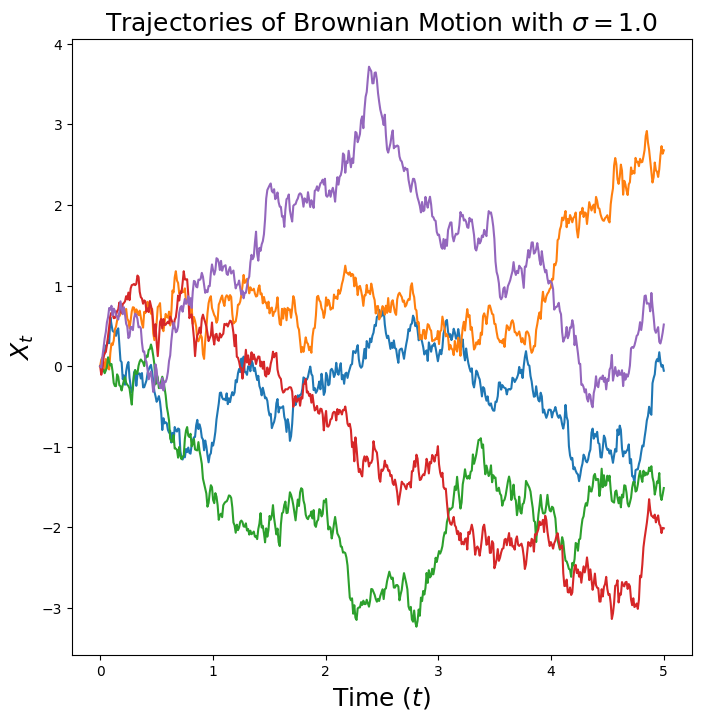

In [8]:
sigma = 1.0
brownian_motion = BrownianMotionSDE(sigma=sigma)
simulator = EulerMaruyamaSolver(sde=brownian_motion)
x0 = torch.zeros(5,1).to(device) # Initial values - let's start at zero
ts = torch.linspace(0.0,5.0,500).to(device) # simulation timesteps

plt.figure(figsize=(8, 8))
ax = plt.gca()
ax.set_title(r'Trajectories of Brownian Motion with $\sigma=$' + str(sigma), fontsize=18)
ax.set_xlabel(r'Time ($t$)', fontsize=18)
ax.set_ylabel(r'$X_t$', fontsize=18)
plot_trajectories_1d(x0=x0, solver=simulator, timesteps=ts, ax=ax)
plt.show()

**Your job**: What happens when you vary the value of `sigma`?

**Your answer**:


---
## Question 2.2: Implementing an Ornstein-Uhlenbeck Process
An OU process is given by setting $u_t(X_t) = - \theta X_t$ and $\sigma_t = \sigma$, viz.,
$$ dX_t = -\theta X_t\, dt + \sigma\, dW_t, \quad \quad X_0 = x_0.$$

**Your job**: Intuitively, what would the trajectory of $X_t$ look like for a very small value of $\theta$? What about a very large value of $\theta$?

**Your answer**:

**Your job**: Fill in the `drift_coefficient` and `difusion_coefficient` methods of the `OUProcess` class below.

In [9]:
class OUProcessSDE(SDE):
    def __init__(self, theta: float, sigma: float):
        self.theta = theta
        self.sigma = sigma
        
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Returns the drift coefficient of the ODE.
        Args:
            - xt: state at time t, shape (bs, dim)
            - t: time, shape ()
        Returns:
            - drift: shape (bs, dim)
        """
        return -self.theta * xt
        
    def diffusion_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Returns the diffusion coefficient of the ODE.
        Args:
            - xt: state at time t, shape (bs, dim)
            - t: time, shape ()
        Returns:
            - diffusion: shape (bs, dim)
        """
        return self.sigma * torch.ones_like(xt)

100%|██████████| 999/999 [00:00<00:00, 54096.64it/s]


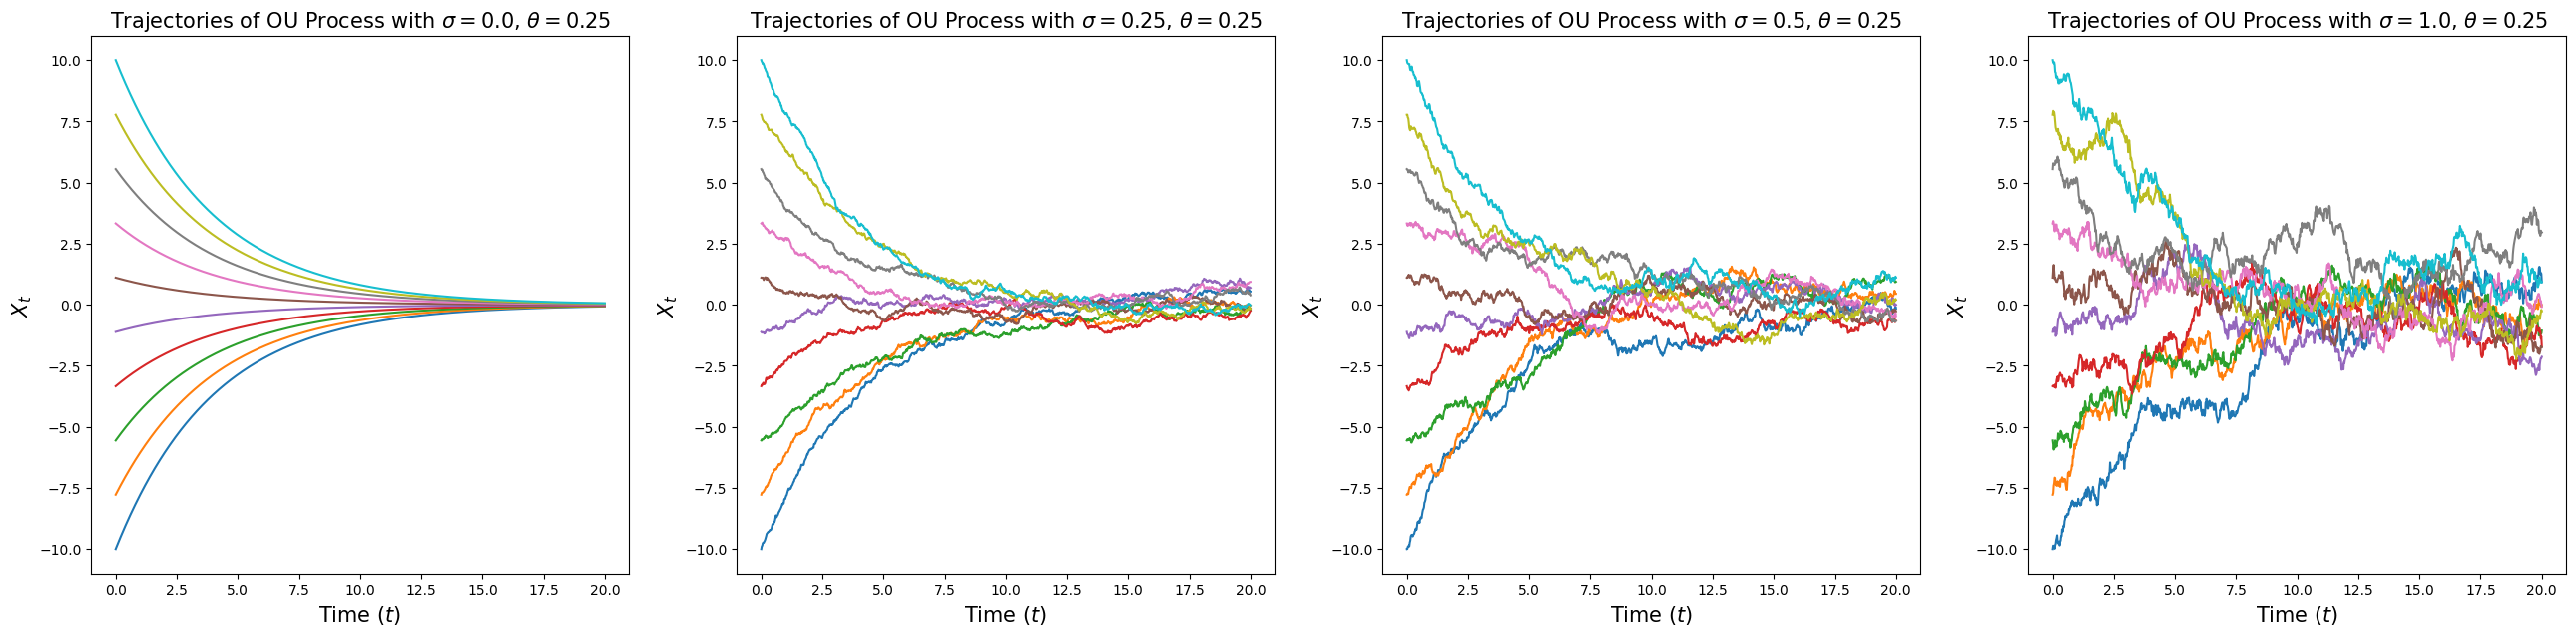

In [10]:
# Try comparing multiple choices side-by-side
thetas_and_sigmas = [
    (0.25, 0.0),
    (0.25, 0.25),
    (0.25, 0.5),
    (0.25, 1.0),
]
simulation_time = 20.0

num_plots = len(thetas_and_sigmas)
fig, axes = plt.subplots(1, num_plots, figsize=(8 * num_plots, 7))

for idx, (theta, sigma) in enumerate(thetas_and_sigmas):
    ou_process = OUProcessSDE(theta, sigma)
    simulator = EulerMaruyamaSolver(sde=ou_process)
    x0 = torch.linspace(-10.0,10.0,10).view(-1,1).to(device) # Initial values - let's start at zero
    ts = torch.linspace(0.0,simulation_time,1000).to(device) # simulation timesteps

    ax = axes[idx]
    ax.set_title(f'Trajectories of OU Process with $\\sigma = ${sigma}, $\\theta = ${theta}', fontsize=15)
    ax.set_xlabel(r'Time ($t$)', fontsize=15)
    ax.set_ylabel(r'$X_t$', fontsize=15)
    plot_trajectories_1d(x0, simulator, ts, ax)
plt.show()

**Your job**: What do you notice about the convergence of the solutions? Are they converging to a particular point? Or to a distribution? Your answer should be two *qualitative* sentences of the form: "When ($\theta$ or $\sigma$) goes (up or down), we see...".

**Hint**: Pay close attention to the ratio $D \triangleq \frac{\sigma^2}{\theta}$ (see the next few cells below!).

**Your answer**:

In [11]:
def plot_scaled_trajectories_1d(x0: torch.Tensor, solver: Solver, 
                                timesteps: torch.Tensor, time_scale: float, 
                                label: str, ax: Optional[Axes] = None):
        """
        Graphs the trajectories of a one-dimensional SDE with given initial values (x0) and simulation timesteps (timesteps).
        Args:
            - x0: state at time t, shape (num_trajectories, 1)
            - solver: Solver object used to simulate
            - t: timesteps to simulate along, shape (num_timesteps,)
            - time_scale: scalar by which to scale time
            - label: self-explanatory
            - ax: pyplot Axes object to plot on
        """
        if ax is None:
            ax = plt.gca()
        trajectories = solver.simulate_with_trajectory(x=x0, ts=timesteps) # (num_trajectories, num_timesteps, ...)
        for trajectory_idx in range(trajectories.shape[0]):
            trajectory = trajectories[trajectory_idx, :, 0] # (num_timesteps,)
            ax.plot(timesteps.cpu() * time_scale, trajectory.cpu(), label=label)

100%|██████████| 999/999 [00:00<00:00, 53640.27it/s]


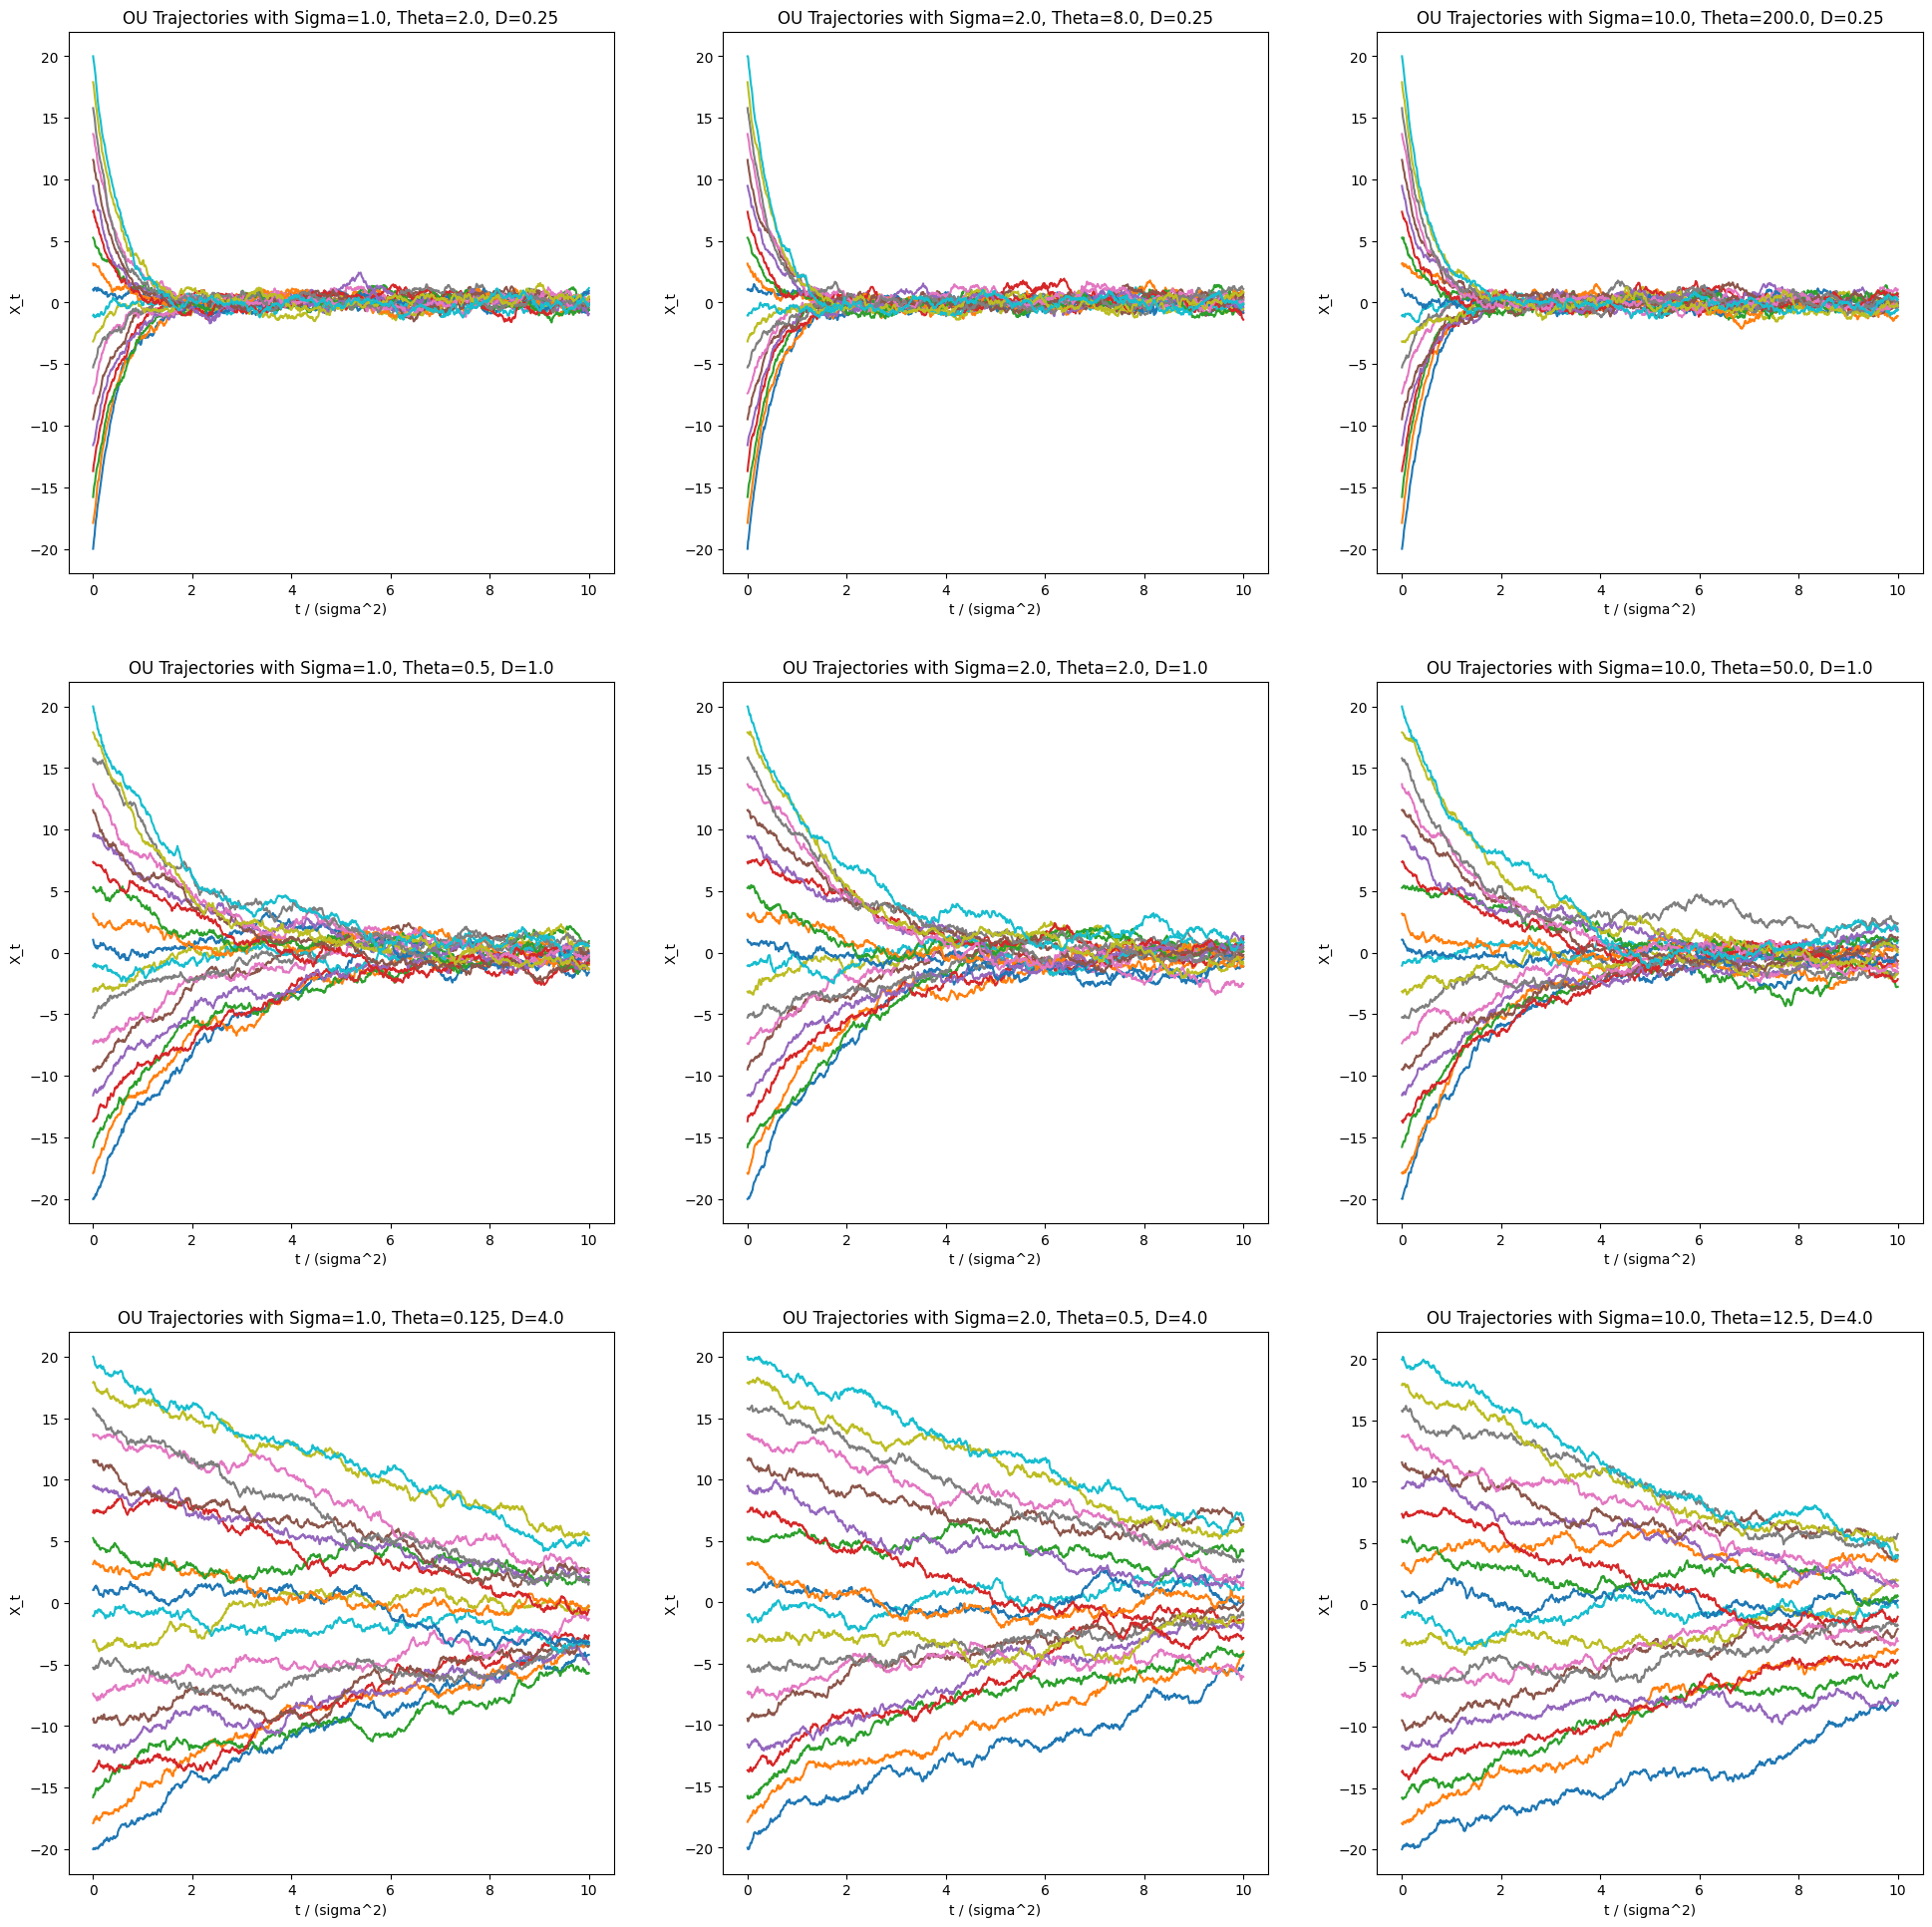

In [12]:
# Let's try rescaling with time
sigmas = [1.0, 2.0, 10.0]
ds = [0.25, 1.0, 4.0] # sigma**2 / 2t
simulation_time = 10.0

fig, axes = plt.subplots(len(ds), len(sigmas), figsize=(8 * len(sigmas), 8 * len(ds)))
axes = axes.reshape((len(ds), len(sigmas)))
for d_idx, d in enumerate(ds):
    for s_idx, sigma in enumerate(sigmas):
        theta = sigma**2 / 2 / d
        ou_process = OUProcessSDE(theta, sigma)
        solver = EulerMaruyamaSolver(sde=ou_process)
        x0 = torch.linspace(-20.0,20.0,20).view(-1,1).to(device)
        time_scale = sigma**2
        ts = torch.linspace(0.0,simulation_time / time_scale,1000).to(device) # simulation timesteps
        ax = axes[d_idx, s_idx]
        plot_scaled_trajectories_1d(x0=x0, solver=solver, timesteps=ts, time_scale=time_scale, label=f'Sigma = {sigma}', ax=ax)
        ax.set_title(f'OU Trajectories with Sigma={sigma}, Theta={theta}, D={d}')
        ax.set_xlabel(f't / (sigma^2)')
        ax.set_ylabel('X_t')
plt.show()

**Your job**: What conclusion can we draw from the figure above? One qualitative sentence is fine. We'll revisit this in Section 3.2.

**Your answer**: